In [60]:
from pymongo import MongoClient
from urllib.parse import quote_plus
import pandas as pd

# MongoDB connection settings
MONGO_HOST = "localhost"
MONGO_PORT = 27017
DB_NAME = "agent_events"          # Change if your DB is named differently
COLLECTION_NAME = "events"  # Change if your collection is named differently

client = MongoClient(f"mongodb://{MONGO_HOST}:{MONGO_PORT}")
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

# Quick connectivity check
print("MongoDB databases:", client.list_database_names())
print("Using:", f"{DB_NAME}.{COLLECTION_NAME}")
print("Estimated docs:", collection.estimated_document_count())

MongoDB databases: ['admin', 'agent_events', 'config', 'forensics', 'local', 'survey', 'test']
Using: agent_events.events
Estimated docs: 384615


In [70]:
# Agent URL patterns we prepared
agent_url_patterns = {
    "open_manus": [
        # "https://h-easy.cheapernyhomes.com/?agent=open-manus",
        # "https://h-hard.cheapernyhomes.com/?agent=open-manus",
        # "https://v2.cheapernyhomes.com/?agent=open-manus",
        # "https://v2-invis.cheapernyhomes.com/?agent=open-manus",
        "https://v3f.cheapernyhomes.com/?agent=open-manus",
        # "https://t.cheapernyhomes.com/?agent=open-manus",
        # "https://t-invis.cheapernyhomes.com/?agent=open-manus",
    ],
    "browser_use": [
        # "https://h-easy.cheapernyhomes.com/?agent=browser-use",
        # "https://h-hard.cheapernyhomes.com/?agent=browser-use",
        # "https://v2.cheapernyhomes.com/?agent=browser-use",
        # "https://v2-invis.cheapernyhomes.com/?agent=browser-use",
        "https://v3f.cheapernyhomes.com/?agent=browser-use",
        # "https://t.cheapernyhomes.com/?agent=browser-use",
        # "https://t-invis.cheapernyhomes.com/?agent=browser-use",
    ],
    "seeact": [
        # "https://h-easy.cheapernyhomes.com/?agent=seeact",
        # "https://h-hard.cheapernyhomes.com/?agent=seeact",
        # "https://v2.cheapernyhomes.com/?agent=seeact",
        # "https://v2-invis.cheapernyhomes.com/?agent=seeact",
        "https://v3f.cheapernyhomes.com/?agent=seeact",
        # "https://t.cheapernyhomes.com/?agent=seeact",
        # "https://t-invis.cheapernyhomes.com/?agent=seeact",
    ],
    "nanobrowser": [
        # "https://h-easy.cheapernyhomes.com/?agent=nano-browser",
        # "https://h-hard.cheapernyhomes.com/?agent=nano-browser",
        # "https://v2.cheapernyhomes.com/?agent=nano-browser",
        # "https://v2-invis.cheapernyhomes.com/?agent=nano-browser",
        "https://v3f.cheapernyhomes.com/?agent=nano-browser",
        # "https://t.cheapernyhomes.com/?agent=nanobrowser",
        # "https://t-invis.cheapernyhomes.com/?agent=nanobrowser",
    ],

}


def fetch_events_for_agent(agent_name, urls, coll):
    query = {"url": {"$in": urls}}
    docs = list(coll.find(query))
    return {
        "agent": agent_name,
        "query": query,
        "count": len(docs),
        "events": docs,
    }


agent_events = {
    agent: fetch_events_for_agent(agent, urls, collection)
    for agent, urls in agent_url_patterns.items()
}

# Keep only agents that have at least one recorded interaction.
agent_events = {
    agent: result
    for agent, result in agent_events.items()
    if result["count"] > 0
}

for agent, result in agent_events.items():
    print(f"{agent}: {result['count']} events")

open_manus: 13 events
browser_use: 75 events
seeact: 15 events
nanobrowser: 98 events


In [71]:
# Build a compact summary table by agent and URL
summary_rows = []

for agent, payload in agent_events.items():
    events = payload["events"]
    per_url_counts = {}
    for e in events:
        u = e.get("url", "<missing>")
        per_url_counts[u] = per_url_counts.get(u, 0) + 1

    for url, count in sorted(per_url_counts.items()):
        summary_rows.append({
            "agent": agent,
            "url": url,
            "event_count": count,
        })

summary_df = pd.DataFrame(summary_rows).sort_values(["agent", "url"]).reset_index(drop=True)
summary_df

,agent,url,event_count
0,browser_use,https://v3f.cheapernyhomes.com/?agent=browser-use,75
1,nanobrowser,https://v3f.cheapernyhomes.com/?agent=nano-browser,98
2,open_manus,https://v3f.cheapernyhomes.com/?agent=open-manus,13
3,seeact,https://v3f.cheapernyhomes.com/?agent=seeact,15


In [72]:
# Optional: inspect raw events for a specific agent/url
agent_to_inspect = "open_manus"
url_to_inspect = "https://v3f.cheapernyhomes.com/?agent=open-manus"

sample = [
    e for e in agent_events[agent_to_inspect]["events"]
    if e.get("url") == url_to_inspect
]

print(f"Found {len(sample)} events for {url_to_inspect}")

# Show first few documents (trimmed)
for i, doc in enumerate(sample[:3], start=1):
    print("\n--- Event", i, "---")
    print({k: doc.get(k) for k in list(doc.keys())[:10]})

Found 13 events for https://v3f.cheapernyhomes.com/?agent=open-manus

--- Event 1 ---
{'_id': ObjectId('69f924d9a7285b6e9f4194db'), 'userId': '5392db28-8f61-41d3-9351-64d635f48c77', 'eventName': 'message', 'timestamp': '1777935576566', 'pos': {'x': 0, 'y': 0}, 'cursor': 0, 'element': '/', 'attrs': '', 'extra': '{"trusted":true}', 'url': 'https://v3f.cheapernyhomes.com/?agent=open-manus'}

--- Event 2 ---
{'_id': ObjectId('69f924d9a7285b6e9f4194dc'), 'userId': '5392db28-8f61-41d3-9351-64d635f48c77', 'eventName': 'message', 'timestamp': '1777935576829', 'pos': {'x': 0, 'y': 0}, 'cursor': 0, 'element': '/', 'attrs': '', 'extra': '{"trusted":true}', 'url': 'https://v3f.cheapernyhomes.com/?agent=open-manus'}

--- Event 3 ---
{'_id': ObjectId('69f924d9a7285b6e9f4194dd'), 'userId': '5392db28-8f61-41d3-9351-64d635f48c77', 'eventName': 'load', 'timestamp': '1777935576848', 'pos': {'x': 0, 'y': 0}, 'cursor': 0, 'element': '/', 'attrs': '', 'extra': '{"trusted":true}', 'url': 'https://v3f.cheaper

In [73]:
# UPDATED COUNTING RULE (robust):
# For each (agent, url), select ONE userId (max event count), then aggregate by agent.
# This version avoids KeyError if notebook cells were run out of order.

if "agent_events" not in globals():
    raise RuntimeError("`agent_events` not found. Run the earlier event-loading cells first.")

source_agents = sorted(list(agent_events.keys()))

# 1) Select one user per (agent, url)
selected_user_per_agent_url = {}
selected_events_per_agent_url = {}

for agent in source_agents:
    payload = agent_events.get(agent, {})
    events = payload.get("events", []) if isinstance(payload, dict) else []

    by_url = {}
    for e in events:
        u = e.get("url")
        if not u:
            continue
        by_url.setdefault(u, []).append(e)

    for url, url_events in by_url.items():
        user_counts = {}
        for e in url_events:
            uid = e.get("userId")
            if uid is None:
                continue
            user_counts[uid] = user_counts.get(uid, 0) + 1

        if user_counts:
            selected_user = sorted(user_counts.items(), key=lambda kv: kv[1], reverse=True)[0][0]
            selected_events = [e for e in url_events if e.get("userId") == selected_user]
        else:
            selected_user = None
            selected_events = []

        selected_user_per_agent_url[(agent, url)] = selected_user
        selected_events_per_agent_url[(agent, url)] = selected_events

# derive actual agents from data keys (prevents missing-key crashes)
agents = sorted({agent for (agent, _url) in selected_events_per_agent_url.keys()})
if not agents:
    agents = source_agents

# 2) Aggregate by agent after per-url user selection
event_counts_by_agent = {agent: {} for agent in agents}
agent_useragent_samples = {agent: {} for agent in agents}
agent_timestamps = {agent: [] for agent in agents}
all_event_names = set()

for (agent, _url), events in selected_events_per_agent_url.items():
    if agent not in event_counts_by_agent:
        event_counts_by_agent[agent] = {}
    if agent not in agent_useragent_samples:
        agent_useragent_samples[agent] = {}
    if agent not in agent_timestamps:
        agent_timestamps[agent] = []

    for e in events:
        event_name = e.get("eventName", "<missing>")
        all_event_names.add(event_name)
        event_counts_by_agent[agent][event_name] = event_counts_by_agent[agent].get(event_name, 0) + 1

        ua = ((e.get("fingerprint") or {}).get("userAgent"))
        if ua:
            agent_useragent_samples[agent][ua] = agent_useragent_samples[agent].get(ua, 0) + 1

        ts_raw = e.get("timestamp")
        try:
            agent_timestamps[agent].append(int(str(ts_raw)))
        except Exception:
            pass

# 3) Build rows: event types + useragent + session_time
rows = []
for event_name in sorted(all_event_names):
    row = {"metric": f"event:{event_name}"}
    for agent in agents:
        row[agent] = event_counts_by_agent.get(agent, {}).get(event_name, 0)
    rows.append(row)

# ua_row = {"metric": "useragent"}
# for agent in agents:
#     ua_counts = agent_useragent_samples.get(agent, {})
#     dominant_ua = sorted(ua_counts.items(), key=lambda kv: kv[1], reverse=True)[0][0] if ua_counts else None
#     ua_row[agent] = dominant_ua
# rows.append(ua_row)

session_row = {"metric": "session_time"}
for agent in agents:
    ts = agent_timestamps.get(agent, [])
    session_row[agent] = round((max(ts) - min(ts)) / 1000.0, 3) if ts else None
rows.append(session_row)

latex_df_per_url_user = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
display(latex_df_per_url_user)

latex_table_per_url_user = latex_df_per_url_user.to_latex(index=False, escape=True)
print(latex_table_per_url_user)

selection_rows = []
for (agent, url), uid in selected_user_per_agent_url.items():
    selection_rows.append(
        {
            "agent": agent,
            "url": url,
            "selected_userId": uid,
            "selected_events": len(selected_events_per_agent_url.get((agent, url), [])),
        }
    )

selection_debug = pd.DataFrame(selection_rows)
if not selection_debug.empty:
    selection_debug = selection_debug.sort_values(["agent", "url"]).reset_index(drop=True)

display(selection_debug)

,metric,browser_use,nanobrowser,open_manus,seeact
0,event:beforeunload,1.000,1.000,1.000,1.000
1,event:blur,2.000,0.000,0.000,0.000
2,event:change,6.000,6.000,2.000,2.000
3,event:click,1.000,1.000,1.000,1.000
4,event:focus,1.000,1.000,0.000,0.000
5,event:keydown,17.000,19.000,0.000,0.000
6,event:keypress,17.000,17.000,0.000,0.000
7,event:keyup,17.000,19.000,0.000,0.000
8,event:load,1.000,1.000,1.000,1.000
9,event:message,2.000,26.000,2.000,2.000


\begin{tabular}{lrrrr}
\toprule
            metric &  browser\_use &  nanobrowser &  open\_manus &  seeact \\
\midrule
event:beforeunload &        1.000 &        1.000 &       1.000 &   1.000 \\
        event:blur &        2.000 &        0.000 &       0.000 &   0.000 \\
      event:change &        6.000 &        6.000 &       2.000 &   2.000 \\
       event:click &        1.000 &        1.000 &       1.000 &   1.000 \\
       event:focus &        1.000 &        1.000 &       0.000 &   0.000 \\
     event:keydown &       17.000 &       19.000 &       0.000 &   0.000 \\
    event:keypress &       17.000 &       17.000 &       0.000 &   0.000 \\
       event:keyup &       17.000 &       19.000 &       0.000 &   0.000 \\
        event:load &        1.000 &        1.000 &       1.000 &   1.000 \\
     event:message &        2.000 &       26.000 &       2.000 &   2.000 \\
   event:mousedown &        1.000 &        1.000 &       1.000 &   1.000 \\
   event:mousemove &        5.000 &        1.

/tmp/ipykernel_15571/3299150221.py:102: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table_per_url_user = latex_df_per_url_user.to_latex(index=False, escape=True)


,agent,url,selected_userId,selected_events
0,browser_use,https://v3f.cheapernyhomes.com/?agent=browser-use,5a1a7558-42a9-4eab-bb27-01cba7d87e4a,75
1,nanobrowser,https://v3f.cheapernyhomes.com/?agent=nano-browser,58fb26e7-af67-402d-a43b-c9e6cac74f37,98
2,open_manus,https://v3f.cheapernyhomes.com/?agent=open-manus,5392db28-8f61-41d3-9351-64d635f48c77,13
3,seeact,https://v3f.cheapernyhomes.com/?agent=seeact,0fa69522-11d1-4021-aa95-934209bb31f4,15


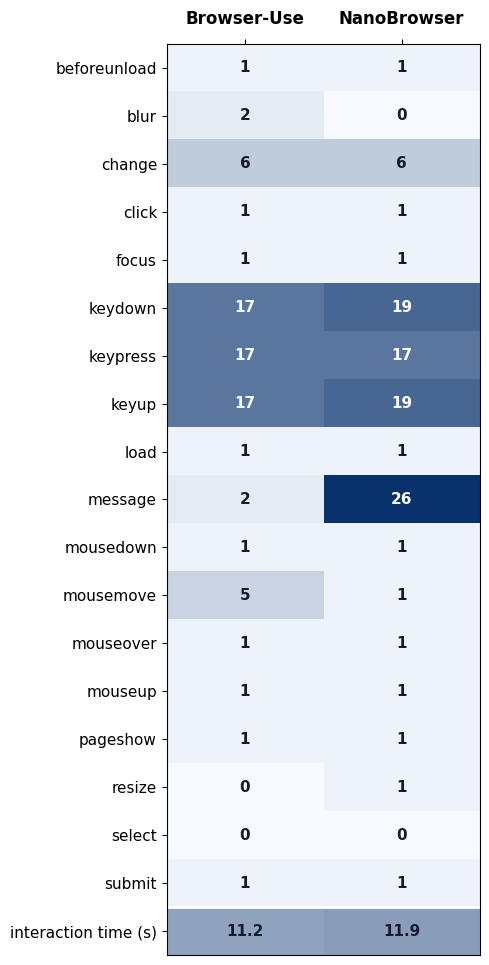

Saved: interaction_heatmap_bu_nb.pdf / .png


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── data ──────────────────────────────────────────────────────────────────────
target_agents = ["browser_use", "nanobrowser"]
agent_labels  = {"browser_use": "Browser-Use", "nanobrowser": "NanoBrowser"}

# Event rows
event_types = sorted(all_event_names)

# Session time row (in seconds, rounded to 1 decimal)
session_times = {
    agent: round((max(agent_timestamps[agent]) - min(agent_timestamps[agent])) / 1000.0, 1)
    if agent_timestamps.get(agent) else 0.0
    for agent in target_agents
}

# Combined row labels and matrix values:
#   first N rows = event counts, last row = interaction time (s)
row_labels = [ev.replace("event:", "") for ev in event_types] + ["interaction time (s)"]

matrix = np.zeros((len(row_labels), len(target_agents)), dtype=float)
for r, ev in enumerate(event_types):
    for c, agent in enumerate(target_agents):
        matrix[r, c] = event_counts_by_agent[agent].get(ev, 0)
for c, agent in enumerate(target_agents):
    matrix[-1, c] = session_times[agent]

col_labels = [agent_labels[a] for a in target_agents]

# ── single global normalisation across all cells ──────────────────────────────
vmax = matrix.max() if matrix.max() > 0 else 1.0

# ── plot ───────────────────────────────────────────────────────────────────────
cmap = mcolors.LinearSegmentedColormap.from_list("wb", ["#f7fbff", "#08306b"])

n_rows, n_cols = matrix.shape
fig, ax = plt.subplots(figsize=(5, 0.45 * n_rows + 1.2))

im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)

# ── tick labels ───────────────────────────────────────────────────────────────
ax.set_xticks(range(n_cols))
ax.set_xticklabels(col_labels, fontsize=12, fontweight="bold")
ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_labels, fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Push x-tick labels up so they don't collide with the cells
ax.tick_params(axis="x", which="both", pad=8)

# ── cell annotations ──────────────────────────────────────────────────────────
for r in range(n_rows):
    for c in range(n_cols):
        raw = matrix[r, c]
        label = f"{raw:.1f}" if r == n_rows - 1 else str(int(raw))
        brightness = raw / vmax
        txt_color  = "white" if brightness > 0.55 else "#1a1a2e"
        ax.text(c, r, label,
                ha="center", va="center",
                fontsize=11, color=txt_color, fontweight="bold")

# horizontal divider before the time row
ax.axhline(n_rows - 1.5, color="white", linewidth=2)

# ax.set_title("Interaction Event Heatmap", fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("interaction_heatmap_bu_nb.pdf", bbox_inches="tight")
# plt.savefig("interaction_heatmap_bu_nb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: interaction_heatmap_bu_nb.pdf / .png")